# Tratamiento y preparación de la señal

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Las cuatro configuraciones del trabajo comparten la misma cadena de tratamiento de señal y la misma
preparación del conjunto de datos. Este informe la documenta una sola vez, de modo que los informes
de cada configuración puedan centrarse en aquello que las distingue.

El contenido sigue paso a paso el apartado **4.3.7** del capítulo de Metodología, dedicado al
tratamiento de la señal. Las operaciones que se describen son las que efectivamente ejecutan los modelos, no una
versión simplificada con fines ilustrativos.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | El material de partida y sus anomalías |
| 2 | Paso 1: filtrado paso banda |
| 3 | Paso 2: alineación de fase |
| 4 | Paso 3: ventaneo del modo S0 |
| 5 | Paso 4: entrada diferencial de dos canales |
| 6 | Paso 5: estandarización y normalización por espécimen |
| 7 | Rasgos escalares para la cabeza híbrida |
| 8 | Preparación del conjunto: de ondas a lotes por espécimen |
| 9 | Aumento de datos |
| 10 | Resumen y limitaciones |

In [1]:
import sys
from pathlib import Path

RAIZ = Path("/")
sys.path.insert(0, str(RAIZ))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config1_cnn_pinn import signals as S
from config1_cnn_pinn.data import (ALL_SPECIMENS, build_specimen_batches,
                                   load_labels, augment, augment_previous)
from physics_calibration.data import load_curve, load_description

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 170)

FS = S.SAMPLING_HZ
print("Constantes de la cadena de preprocesado")
print(f"  frecuencia de muestreo    {S.SAMPLING_HZ/1e6:.0f} MHz")
print(f"  muestras por registro     {S.N_SAMPLES}  ({S.N_SAMPLES/S.SAMPLING_HZ*1e6:.0f} µs)")
print(f"  excitación                {S.EXCITATION_HZ/1e3:.0f} kHz")
print(f"  banda de paso             {S.BAND_HZ[0]/1e3:.0f} - {S.BAND_HZ[1]/1e3:.0f} kHz")
print(f"  ventana del modo S0       {S.WINDOW_S[0]*1e6:.0f} - {S.WINDOW_S[1]*1e6:.0f} us"
      f"  ->  {S.WINDOW_SAMPLES} muestras por canal")
print(f"  descartado de la traza    {100*(1 - S.WINDOW_SAMPLES/S.N_SAMPLES):.1f} %")

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"

def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


Constantes de la cadena de preprocesado
  frecuencia de muestreo    20 MHz
  muestras por registro     4000  (200 µs)
  excitación                200 kHz
  banda de paso             100 - 400 kHz
  ventana del modo S0       90 - 145 us  ->  1100 muestras por canal
  descartado de la traza    72.5 %


## 1. El material de partida y sus anomalías

El conjunto de datos publicado contiene ocho especímenes de junta traslapada remachada de aluminio
2024-T3. De cada uno se dispone de registros de ondas de Lamb en un subconjunto de ciclos, con dos
repeticiones por medida, y de una curva de longitud de grieta medida ópticamente.

La cantidad de datos disponible condiciona todas las decisiones posteriores, por lo que se cuantifica
en primer lugar.

In [2]:
filas = []
etiquetas = load_labels()
for esp in ALL_SPECIMENS:
    ciclos = S.signal_cycles(name=esp)
    etq = dict(zip(etiquetas[esp]["cycle"], etiquetas[esp]["crack_length_mm"]))
    con_etiqueta = [c for c in ciclos if c in etq]
    ondas = sum(len(S.available_repetitions(S.DEFAULT_ROOT, esp, c)) for c in con_etiqueta
                if (esp, c) not in S.EXCLUDED_RECORDS)
    filas.append({
        "especimen": esp,
        "grupo": "entrenamiento" if esp in S.TRAINING_SPECIMENS else "validacion",
        "ciclos con senal": len(ciclos),
        "de ellos etiquetados": len(con_etiqueta),
        "ondas utilizables": ondas,
        "grieta final (mm)": round(float(load_curve(esp).final_crack_mm), 2),
        "ultimo ciclo con senal": max(ciclos),
    })
inventario = pd.DataFrame(filas)
print(f"TOTAL de ondas etiquetadas utilizables: {inventario['ondas utilizables'].sum()}")
inventario


TOTAL de ondas etiquetadas utilizables: 87


,especimen,grupo,ciclos con senal,de ellos etiquetados,ondas utilizables,grieta final (mm),ultimo ciclo con senal
0,T1,entrenamiento,7,7,14,7.46,70766
1,T2,entrenamiento,3,3,6,4.95,72000
2,T3,entrenamiento,10,9,18,6.93,66510
3,T4,entrenamiento,8,8,16,7.24,75045
4,T5,entrenamiento,3,3,5,3.64,56000
5,T6,entrenamiento,6,6,12,5.08,73211
6,T7,validacion,4,4,8,7.22,47022
7,T8,validacion,5,5,8,5.52,76931


### 1.1 Anomalías del conjunto y tratamiento aplicado

El conjunto presenta defectos documentados que no pueden ignorarse sin comprometer el
entrenamiento. Cada uno recibe un tratamiento explícito:

| Anomalía | Tratamiento aplicado |
|---|---|
| No existen los registros del ciclo cero que menciona la documentación | Como referencia sin daño se toma el primer ciclo medido de cada espécimen |
| El registro de T8 en el ciclo 40000 difiere por completo del resto de T8 | Se excluye y se toma el ciclo 50000 como referencia de ese espécimen |
| El registro de T1 en el ciclo 50000 tiene repeticiones incompatibles entre sí | Se emplea de forma uniforme la primera repetición para toda referencia |
| El ciclo 55391 de T3 dispone de señal pero carece de etiqueta | Se descarta al construir las muestras, al no existir supervisión |
| La carpeta del ciclo 42000 de T5 está vacía | No se incorpora al inventario de ciclos con señal |
| T5 es el espécimen atípico reconocido por la organización | Se conserva como dato de entrenamiento, pero nunca como partición de validación |

La exclusión del registro de T8 en el ciclo 40000 merece justificarse. Ese registro está etiquetado
con grieta nula, de modo que conservarlo equivale a enseñar al codificador que una onda corrompida
corresponde a un estado sin daño. El equipo ganador del certamen lo descarta por el mismo motivo.

Conviene precisar en qué evidencia se apoya esa exclusión. Existe una descripción previa que
atribuye al registro un desfase de unos 10 µs respecto del resto de T8, cifra que **no se ha podido
reproducir**: ni la correlación cruzada del canal receptor, que da −0.65 µs, ni el instante de
llegada del paquete medido por umbral de envolvente, que queda dentro de ±0.75 µs frente a tres de
los cuatro registros restantes, se aproximan a ese valor. El estadístico que sí separa el registro
de forma inequívoca es la correlación de la onda ventaneada, que se calcula a continuación y coincide
con lo que muestra la figura 8(d) de Kong *et al.* La exclusión queda por tanto justificada, si bien
la cifra de 10 µs no se emplea aquí como evidencia.

In [3]:
print("Registros excluidos por estar corrompidos:")
for esp, ciclo in S.EXCLUDED_RECORDS:
    print(f"  espécimen {esp}, ciclo {ciclo}")
print("\nEspecímenes cuya referencia sin daño se sustituye:")
for esp, ciclo in S.REFERENCE_CYCLE_OVERRIDE.items():
    print(f"  {esp}: se emplea el ciclo {ciclo} en lugar del primero medido")
print()
print("Ciclo de referencia efectivo por especimen:")
for esp in ALL_SPECIMENS:
    motivo = " (sobrescrito: el 40000 es anomalo)" if esp in S.REFERENCE_CYCLE_OVERRIDE else ""
    print(f"  {esp}: {S.reference_cycle(esp):>7}{motivo}")

ondas_t8 = {c: S.zscore(S.load_waveform("T8", c, 1)) for c in S.signal_cycles(name="T8")}
ciclos_t8 = list(ondas_t8)
matriz = pd.DataFrame(
    [[float(np.corrcoef(ondas_t8[a], ondas_t8[b])[0, 1]) for b in ciclos_t8]
     for a in ciclos_t8],
    index=ciclos_t8, columns=ciclos_t8,
).round(3)
print("\nCorrelacion de la onda ventaneada entre ciclos de T8:")
print(matriz.to_string())

fuera = [matriz.loc[40000, c] for c in ciclos_t8 if c != 40000]
resto = [matriz.loc[a, b] for a in ciclos_t8 for b in ciclos_t8
         if a < b and 40000 not in (a, b)]
print(f"\n  40000 frente al resto : {min(fuera):.3f} - {max(fuera):.3f}")
print(f"  el resto entre si     : {min(resto):.3f} - {max(resto):.3f}")
print("  -> el registro de 40000 no se parece a ninguno de los demas de su propio especimen,")
print("     por lo que no puede servir de referencia sin dano. Se adopta el ciclo 50000.")


Registros excluidos por estar corrompidos:
  espécimen T8, ciclo 40000

Especímenes cuya referencia sin daño se sustituye:
  T8: se emplea el ciclo 50000 en lugar del primero medido

Ciclo de referencia efectivo por especimen:
  T1:   50000
  T2:   50000
  T3:   14000
  T4:   55900
  T5:   46000
  T6:   55000
  T7:   36001
  T8:   50000 (sobrescrito: el 40000 es anomalo)

Correlacion de la onda ventaneada entre ciclos de T8:
       40000  50000  70000  74883  76931
40000  1.000  0.291  0.480  0.266  0.270
50000  0.291  1.000  0.879  0.885  0.841
70000  0.480  0.879  1.000  0.676  0.642
74883  0.266  0.885  0.676  1.000  0.991
76931  0.270  0.841  0.642  0.991  1.000

  40000 frente al resto : 0.266 - 0.480
  el resto entre si     : 0.642 - 0.991
  -> el registro de 40000 no se parece a ninguno de los demas de su propio especimen,
     por lo que no puede servir de referencia sin dano. Se adopta el ciclo 50000.


## 2. Paso 1: filtrado paso banda

La excitación es un tren de ondas centrado en 200 kHz y la señal recibida contiene sus ecos
dispersados. El contenido situado fuera del intervalo de 100 a 400 kHz corresponde a ruido eléctrico
de la cadena de adquisición.

Se aplica un filtro Butterworth de cuarto orden en esa banda, en implementación de fase nula: la
señal se filtra hacia delante y hacia atrás, de manera que el filtrado no introduzca retardo de
grupo. Esa propiedad es necesaria, no accesoria, porque un filtro causal desplazaría la señal en el
tiempo y el retardo forma parte precisamente de la firma del daño que la red debe leer.

Los tres métodos premiados filtran en bandas equivalentes: de 100 a 500 kHz el primero, de 150 a
350 kHz el segundo y de 100 a 500 kHz el tercero con un filtro de respuesta finita al impulso de
fase lineal. La banda adoptada aquí es intermedia entre la más ancha y la más estrecha.

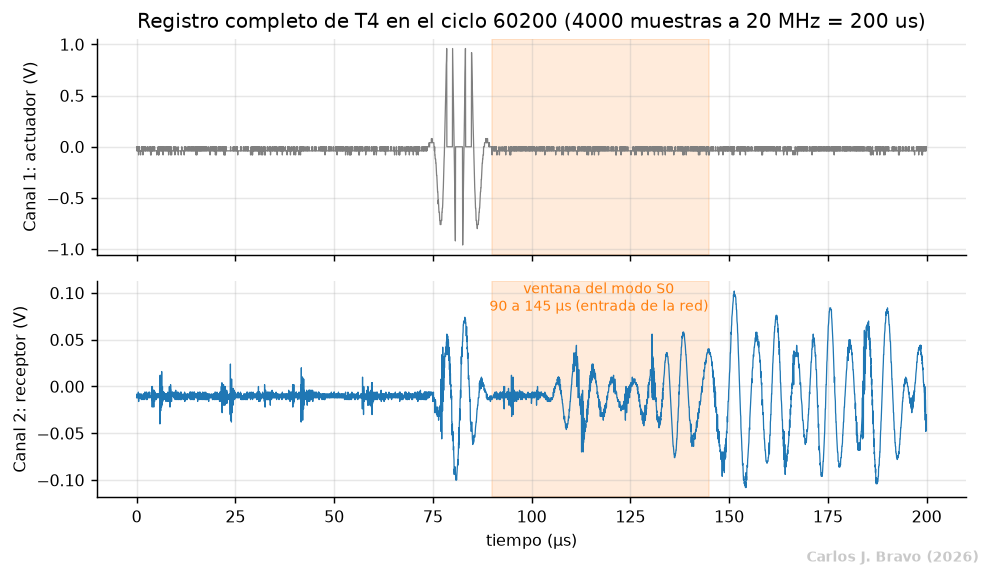

In [4]:
ESPECIMEN, CICLO = "T4", 60200
ch1, ch2 = S._load_raw(ESPECIMEN, CICLO, 1, None)
t = np.arange(len(ch2)) / FS * 1e6

fig, ejes = plt.subplots(2, 1, figsize=(7.6, 4.4), sharex=True)
ejes[0].plot(t, ch1, lw=0.7, color="tab:gray")
ejes[0].set_ylabel("Canal 1: actuador (V)")
ejes[0].set_title(f"Registro completo de {ESPECIMEN} en el ciclo {CICLO} "
                  f"({S.N_SAMPLES} muestras a {FS/1e6:.0f} MHz = {S.N_SAMPLES/FS*1e6:.0f} us)")
ejes[1].plot(t, ch2, lw=0.7, color="tab:blue")
ejes[1].set_ylabel("Canal 2: receptor (V)")
ejes[1].set_xlabel("tiempo (µs)")
for eje in ejes:
    eje.axvspan(S.WINDOW_S[0]*1e6, S.WINDOW_S[1]*1e6, color="tab:orange", alpha=0.15)
ejes[1].annotate("ventana del modo S0\n90 a 145 µs (entrada de la red)",
                 xy=(117, ejes[1].get_ylim()[1]*0.72), ha="center", fontsize=8, color="tab:orange")
fig.tight_layout()
marca_de_agua(fig)
plt.show()


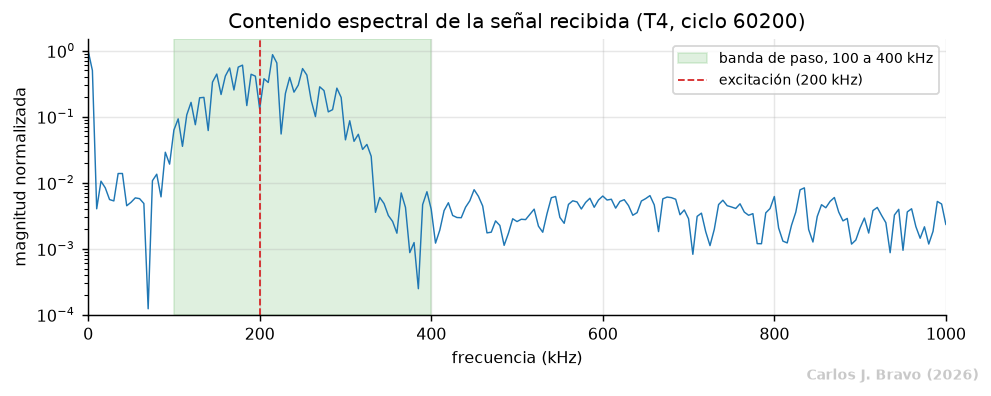

Energia espectral fuera de la banda de paso: 23.7 % del total


In [5]:
espectro = np.abs(np.fft.rfft(ch2 * np.hanning(len(ch2))))
frec = np.fft.rfftfreq(len(ch2), 1/FS) / 1e3

fig, eje = plt.subplots(figsize=(7.6, 3.0))
eje.semilogy(frec, espectro/espectro.max(), lw=0.8, color="tab:blue")
eje.axvspan(S.BAND_HZ[0]/1e3, S.BAND_HZ[1]/1e3, color="tab:green", alpha=0.15,
            label="banda de paso, 100 a 400 kHz")
eje.axvline(S.EXCITATION_HZ/1e3, color="tab:red", ls="--", lw=1, label="excitación (200 kHz)")
eje.set(xlim=(0, 1000), ylim=(1e-4, 1.5), xlabel="frecuencia (kHz)",
        ylabel="magnitud normalizada",
        title=f"Contenido espectral de la señal recibida ({ESPECIMEN}, ciclo {CICLO})")
eje.legend(loc="upper right", fontsize=8)
fig.tight_layout()
marca_de_agua(fig)
plt.show()

fuera = espectro[(frec < S.BAND_HZ[0]/1e3) | (frec > S.BAND_HZ[1]/1e3)]
print(f"Energia espectral fuera de la banda de paso: "
      f"{100*np.sum(fuera**2)/np.sum(espectro**2):.1f} % del total")


## 3. Paso 2: alineación de fase

El daño se manifiesta como un retardo inferior a un microsegundo acompañado de un cambio de forma
del paquete S0. La incertidumbre de disparo del sistema de adquisición es del mismo orden de
magnitud, de modo que dos registros del mismo espécimen pueden empezar a contar el tiempo con
décimas de microsegundo de diferencia. Sin corregir ese desajuste, el canal diferencial mediría
sobre todo el desfase de adquisición y no el daño.

Dos decisiones de implementación condicionan el resultado:

1. **El desplazamiento se mide sobre el canal del actuador y se aplica al del receptor.** El
   actuador reproduce el mismo tren de ondas en todos los registros y no porta información de daño,
   por lo que cualquier diferencia suya respecto de la referencia es, por definición, desajuste de
   disparo.
2. **La medida se realiza por correlación cruzada y no por la posición del máximo absoluto.** El
   tren de excitación presenta dos picos de amplitud casi igual, de forma que el máximo salta de uno
   al otro entre registros e introduce un error de un período completo de la portadora. La regla del
   máximo es la que emplea Kong *et al.* y la que aquí resultó necesario sustituir.

Las medidas obtenidas matizan el alcance de este paso. Cuantificado sobre los ocho especímenes, el
desplazamiento que arroja la correlación no supera **una muestra, esto es 0.05 µs**: los registros ya
vienen alineados, y la corrección resulta en este conjunto de datos prácticamente inocua. Lo que sí
queda demostrado es la segunda decisión: la regla del máximo absoluto produce desplazamientos de 81
a 125 muestras, entre 4 y 6 µs, equivalentes a uno o más períodos completos de portadora, que sí
habrían degradado el canal diferencial. El paso se conserva, por tanto, como salvaguarda frente a un
desajuste que este conjunto no presenta, y no como una corrección determinante.

In [6]:
esp = "T4"
ref_ch1, _ = S._load_raw(esp, S.reference_cycle(esp), 1, None)
filas = []
for ciclo in S.signal_cycles(name=esp):
    ch1_i, _ = S._load_raw(esp, ciclo, 1, None)
    corr = np.correlate(ch1_i, ref_ch1, mode="full")
    lag_xcorr = int(np.argmax(corr)) - (len(ref_ch1) - 1)
    lag_argmax = int(np.argmax(np.abs(ch1_i))) - int(np.argmax(np.abs(ref_ch1)))
    filas.append({"ciclo": ciclo,
                  "lag por correlacion (muestras)": lag_xcorr,
                  "lag por maximo absoluto (muestras)": lag_argmax,
                  "discrepancia (us)": round((lag_argmax - lag_xcorr)/FS*1e6, 3)})
comparacion = pd.DataFrame(filas)
periodo_us = 1e6 / S.EXCITATION_HZ
print(f"Período de la portadora a {S.EXCITATION_HZ/1e3:.0f} kHz: {periodo_us:.1f} µs "
      f"= {periodo_us*FS/1e6:.0f} muestras")
print(f"Registros en que las dos reglas discrepan: "
      f"{(comparacion['discrepancia (us)'].abs() > 1e-9).sum()} de {len(comparacion)}")

print("\nDesplazamiento medido por correlacion en ch1, todo el dataset:")
peor = 0
for esp in S.TRAINING_SPECIMENS + S.VALIDATION_SPECIMENS:
    ref_e, _ = S._load_raw(esp, S.reference_cycle(esp), 1, None)
    lags = []
    for ciclo in S.signal_cycles(name=esp):
        for rep in S.available_repetitions(S.DEFAULT_ROOT, esp, ciclo):
            c1, _ = S._load_raw(esp, ciclo, rep, None)
            cc = np.correlate(c1, ref_e, mode="full")
            lags.append(int(np.argmax(cc)) - (len(ref_e) - 1))
    lags = np.array(lags)
    peor = max(peor, int(np.abs(lags).max()))
    print(f"  {esp}: n = {len(lags):>3} registros | lag de {lags.min():>2} a {lags.max():>2} "
          f"muestras | |max| = {np.abs(lags).max()/FS*1e6:.2f} us")
print(f"\n  Peor desajuste de todo el dataset: {peor} muestra(s) = {peor/FS*1e6:.2f} us")
print(f"  Error que introduciria la regla del maximo absoluto: hasta "
      f"{int(comparacion['lag por maximo absoluto (muestras)'].abs().max())} muestras = "
      f"{comparacion['discrepancia (us)'].abs().max():.2f} us")
comparacion


Período de la portadora a 200 kHz: 5.0 µs = 100 muestras
Registros en que las dos reglas discrepan: 7 de 8

Desplazamiento medido por correlacion en ch1, todo el dataset:
  T1: n =  14 registros | lag de -1 a  0 muestras | |max| = 0.05 us
  T2: n =   6 registros | lag de  0 a  1 muestras | |max| = 0.05 us
  T3: n =  20 registros | lag de  0 a  1 muestras | |max| = 0.05 us
  T4: n =  16 registros | lag de  0 a  1 muestras | |max| = 0.05 us


  T5: n =   5 registros | lag de  0 a  1 muestras | |max| = 0.05 us


  T6: n =  12 registros | lag de -1 a  0 muestras | |max| = 0.05 us
  T7: n =   8 registros | lag de  0 a  1 muestras | |max| = 0.05 us
  T8: n =  10 registros | lag de  0 a  0 muestras | |max| = 0.00 us

  Peor desajuste de todo el dataset: 1 muestra(s) = 0.05 us
  Error que introduciria la regla del maximo absoluto: hasta 125 muestras = 6.30 us


,ciclo,lag por correlacion (muestras),lag por maximo absoluto (muestras),discrepancia (us)
0,55900,0,0,0.00
1,60200,1,-125,-6.30
2,65001,1,-125,-6.30
3,67054,0,-81,-4.05
4,70016,0,-81,-4.05
5,71130,1,-125,-6.30
6,73210,1,-125,-6.30
7,75045,0,-95,-4.75


## 4. Paso 3: ventaneo del modo S0

De los 200 µs de traza únicamente el primer paquete de llegada, el modo S0, porta la firma del daño
de forma limpia; lo que llega después se solapa con ecos de los bordes y con reverberación. Ese
paquete llega entre los 100 y los 130 µs.

La ventana extraída abarca de 90 a 145 µs, deliberadamente más ancha que el paquete, de modo que la
selección del tramo informativo la realicen las convoluciones y no un ajuste manual. Descarta la
mayor parte de la traza, tanto el silencio previo a la llegada como la reverberación posterior, y
deja 1100 muestras por canal.

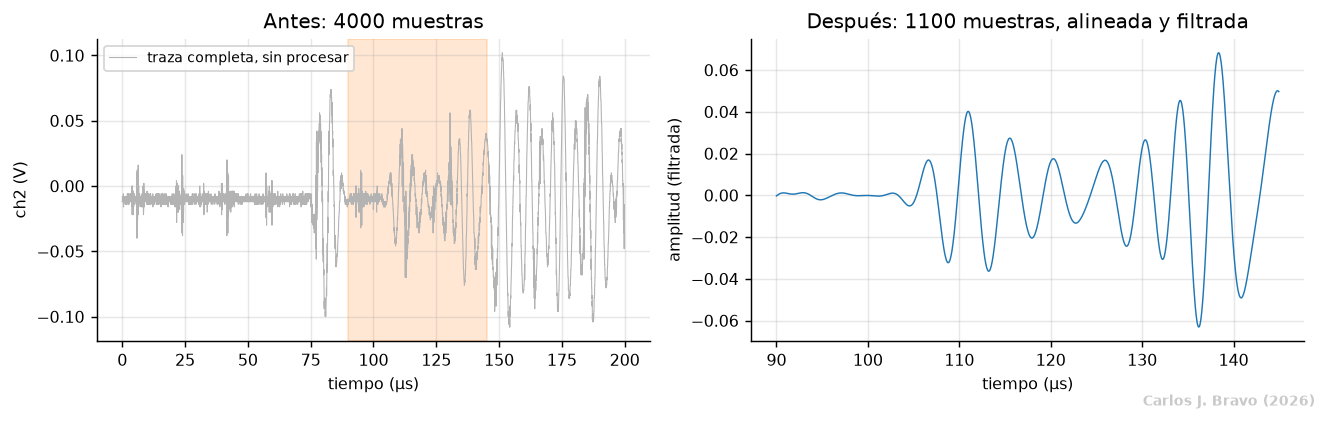

Traza completa : 4000 muestras
Ventana S0     : 1100 muestras (27.5 % de la traza)
Descartado     : 72.5 %


In [7]:
onda_ventaneada = S.load_waveform(ESPECIMEN, CICLO, 1)
t_v = (np.arange(S.WINDOW_SAMPLES)/FS + S.WINDOW_S[0]) * 1e6

fig, ejes = plt.subplots(1, 2, figsize=(10.2, 3.2))
ejes[0].plot(t, ch2, lw=0.6, color="0.7", label="traza completa, sin procesar")
ejes[0].axvspan(S.WINDOW_S[0]*1e6, S.WINDOW_S[1]*1e6, color="tab:orange", alpha=0.18)
ejes[0].set(xlabel="tiempo (µs)", ylabel="ch2 (V)", title="Antes: 4000 muestras")
ejes[0].legend(fontsize=7.5)
ejes[1].plot(t_v, onda_ventaneada, lw=0.8, color="tab:blue")
ejes[1].set(xlabel="tiempo (µs)", ylabel="amplitud (filtrada)",
            title=f"Después: {S.WINDOW_SAMPLES} muestras, alineada y filtrada")
fig.tight_layout()
marca_de_agua(fig)
plt.show()

print(f"Traza completa : {S.N_SAMPLES} muestras")
print(f"Ventana S0     : {S.WINDOW_SAMPLES} muestras "
      f"({100*S.WINDOW_SAMPLES/S.N_SAMPLES:.1f} % de la traza)")
print(f"Descartado     : {100*(1-S.WINDOW_SAMPLES/S.N_SAMPLES):.1f} %")


## 5. Paso 4: entrada diferencial de dos canales

La red no recibe la onda absoluta, sino dos canales:

| Canal | Contenido |
|---|---|
| 0 | la onda estandarizada del ciclo actual |
| 1 | su diferencia respecto del registro sin daño del mismo espécimen |

El motivo es que la amplitud absoluta no resulta comparable entre probetas: el pegado del
transductor y el ajuste de los remaches varían de una a otra más de lo que varía la propia firma del
daño. Restar el registro sano de la misma probeta cancela esa variabilidad y deja únicamente lo que
ha cambiado en ella desde que estaba intacta.

Se trata de la única pieza de conocimiento físico introducida manualmente en el preprocesado. El
resto de descriptores, como el tiempo de vuelo, la energía espectral o el desfase, se dejan al
aprendizaje de las convoluciones. La idea procede del método ganador, que la aplica sobre rasgos
escalares; aquí opera sobre la forma de onda completa.

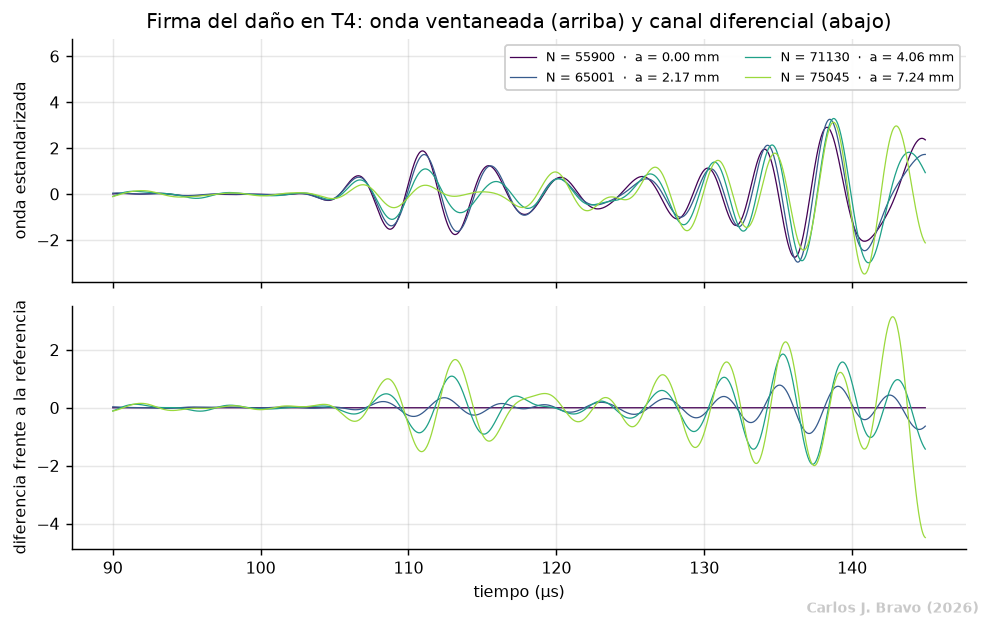

La curva del ciclo de referencia tiene diferencia identicamente nula, por construccion:
  N =  55900  a = 0.00 mm   RMS del canal diferencial = 0.0000
  N =  65001  a = 2.17 mm   RMS del canal diferencial = 0.2660
  N =  71130  a = 4.06 mm   RMS del canal diferencial = 0.6133
  N =  75045  a = 7.24 mm   RMS del canal diferencial = 0.9938


In [8]:
esp = "T4"
etq = dict(zip(*load_description(name=esp).to_dict("list").values()))
ciclos = [c for c in S.signal_cycles(name=esp) if c in etq]
elegidos = [ciclos[0], ciclos[len(ciclos)//3], ciclos[2*len(ciclos)//3], ciclos[-1]]
referencia = S.reference_waveform(esp)

fig, ejes = plt.subplots(2, 1, figsize=(7.6, 4.8), sharex=True)
colores = plt.cm.viridis(np.linspace(0, 0.85, len(elegidos)))
for ciclo, color in zip(elegidos, colores):
    onda = S.zscore(S.load_waveform(esp, ciclo, 1))
    ejes[0].plot(t_v, onda, lw=0.7, color=color,
                 label=f"N = {ciclo}  ·  a = {etq[ciclo]:.2f} mm")
    ejes[1].plot(t_v, onda - referencia, lw=0.7, color=color)
ejes[0].set_ylabel("onda estandarizada")
ejes[0].set_title(f"Firma del daño en {esp}: onda ventaneada (arriba) "
                  "y canal diferencial (abajo)")
inf, sup = ejes[0].get_ylim()
ejes[0].set_ylim(inf, sup + 0.42*(sup-inf))
ejes[0].legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.95)
ejes[1].set(ylabel="diferencia frente a la referencia", xlabel="tiempo (µs)")
fig.tight_layout()
marca_de_agua(fig)
plt.show()

print("La curva del ciclo de referencia tiene diferencia identicamente nula, por construccion:")
for ciclo in elegidos:
    d = S.zscore(S.load_waveform(esp, ciclo, 1)) - referencia
    print(f"  N = {ciclo:>6}  a = {etq[ciclo]:>4.2f} mm   RMS del canal diferencial = "
          f"{np.sqrt(np.mean(d**2)):.4f}")


## 6. Paso 5: estandarización y normalización por espécimen

El paso comprende dos operaciones distintas, una sobre cada canal, que conviene no confundir.

**Estandarización de cada onda.** A cada onda se le resta su media y se divide por su desviación
típica, de modo que todas entren con la misma amplitud. Con ello se elimina la ganancia de
acoplamiento del transductor, que depende del pegado del piezoeléctrico y varía entre especímenes y
a lo largo de la vida de cada uno. Es información sobre el sensor, no sobre la grieta.

**Normalización del canal diferencial por espécimen.** Igualar la amplitud de las ondas no iguala el
tamaño de su diferencia: cada probeta está instrumentada sobre un par actuador-sensor distinto, por
lo que la distancia de propagación y el número de filas de remaches atravesadas difieren. Sin
corregirlo, la red interpretaría esa amplitud como longitud de grieta. La corrección divide el canal
diferencial por un valor de referencia leído en un estado de daño por el que pasan las ocho probetas:
la primera medida cuya grieta alcanza 2 mm.

La alternativa aparentemente natural, dividir por el máximo de cada espécimen, resulta
sistemáticamente sesgada. El máximo se alcanza en un estado de daño distinto en cada probeta, y los
especímenes de validación pierden la señal mucho antes que los de entrenamiento: su última medida
útil está en 3.14 mm para T7 y 2.50 mm para T8, frente a valores de 5 a 7.5 mm en los demás. Sus
máximos resultan por tanto menores, dividir por ellos infla su canal diferencial, y la red
sobreestimaría precisamente los dos especímenes sobre los que se juzga todo el trabajo.

Esta normalización no tiene precedente en los métodos del certamen, que refieren sus rasgos al
registro sano de cada espécimen pero no los reescalan entre especímenes.

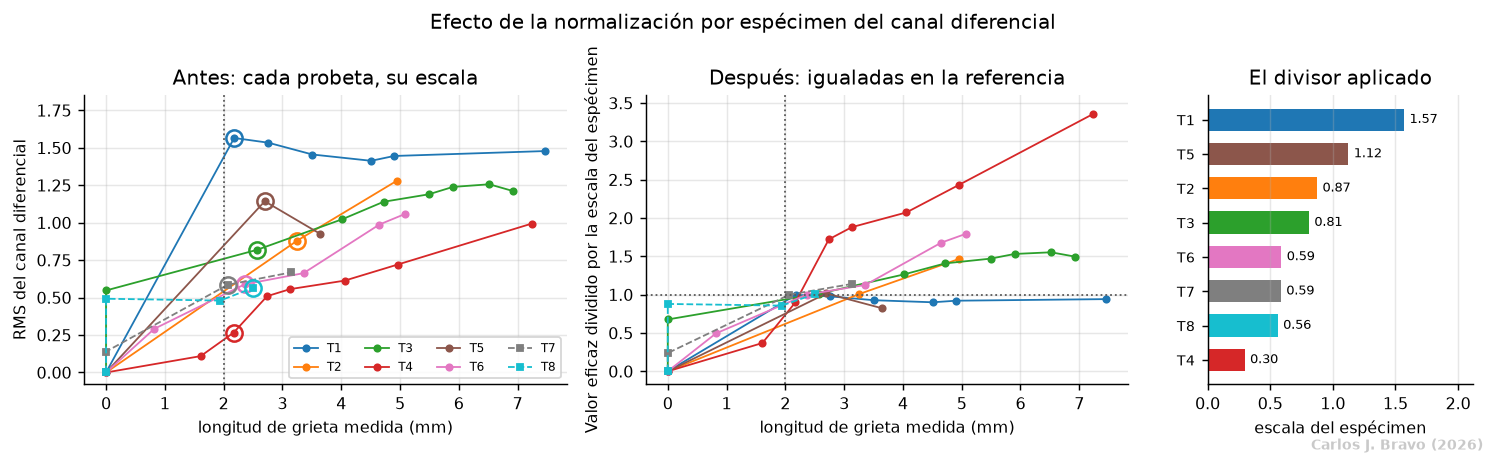

Divisor mayor / menor = x5.3  (T1 = 1.57 frente a T4 = 0.30)


In [9]:
REFERENCIA_MM = 2.0
colores = dict(zip(ALL_SPECIMENS, plt.cm.tab10(np.linspace(0, 0.9, len(ALL_SPECIMENS)))))

curvas, anclas = {}, {}
for esp in ALL_SPECIMENS:
    etq_e = dict(zip(*load_description(name=esp).to_dict("list").values()))
    puntos = []
    for ciclo in S.signal_cycles(name=esp):
        if ciclo not in etq_e or (esp, ciclo) in S.EXCLUDED_RECORDS:
            continue
        par = S.encode(esp, ciclo, 1, normalise_difference=False)
        puntos.append((etq_e[ciclo], float(np.sqrt(np.mean(par[1]**2)))))
    puntos.sort()
    curvas[esp] = puntos
    cand = [p for p in puntos if p[0] >= REFERENCIA_MM]
    anclas[esp] = min(cand, key=lambda p: p[0]) if cand else max(puntos)

escalas = {esp: S.difference_scale(esp) for esp in ALL_SPECIMENS}

fig, ejes = plt.subplots(1, 3, figsize=(11.5, 3.4),
                         gridspec_kw={"width_ratios": [2, 2, 1.1]})
for esp in ALL_SPECIMENS:
    x, y = zip(*curvas[esp])
    marcador = "s--" if esp in ("T7", "T8") else "o-"
    ejes[0].plot(x, y, marcador, ms=3.5, lw=1, color=colores[esp], label=esp)
    ejes[0].plot(*anclas[esp], "o", ms=9, mfc="none", mew=1.4, color=colores[esp])
    ejes[1].plot(x, np.array(y)/escalas[esp], marcador, ms=3.5, lw=1, color=colores[esp])
for eje, tope in ((ejes[0], 1.85), (ejes[1], 3.6)):
    eje.axvline(REFERENCIA_MM, color="0.35", ls=":", lw=1)
    eje.set_xlabel("longitud de grieta medida (mm)")
    eje.set_ylim(top=tope)
ejes[1].axhline(1.0, color="0.35", ls=":", lw=1)
ejes[0].set(ylabel="RMS del canal diferencial", title="Antes: cada probeta, su escala")
ejes[0].legend(fontsize=6.5, ncol=4, loc="lower right")
ejes[1].set(ylabel="Valor eficaz dividido por la escala del espécimen", title="Después: igualadas en la referencia")

orden = sorted(ALL_SPECIMENS, key=lambda e: escalas[e])
valores = [escalas[e] for e in orden]
ejes[2].barh(range(len(orden)), valores, color=[colores[e] for e in orden], height=0.65)
for i, v in enumerate(valores):
    ejes[2].annotate(f"{v:.2f}", xy=(v, i), xytext=(3, 0), textcoords="offset points",
                     va="center", fontsize=7)
ejes[2].set_yticks(range(len(orden)), orden, fontsize=8)
ejes[2].set(xlim=(0, max(valores)*1.35), xlabel="escala del espécimen", title="El divisor aplicado")
ejes[2].grid(axis="y", visible=False)
fig.suptitle("Efecto de la normalización por espécimen del canal diferencial", y=1.0)
fig.tight_layout()
marca_de_agua(fig)
plt.show()

print(f"Divisor mayor / menor = x{max(valores)/min(valores):.1f}  "
      f"({orden[-1]} = {max(valores):.2f} frente a {orden[0]} = {min(valores):.2f})")


In [10]:
def dispersion(banda=(2.0, 2.5), normalizado=False):
    vals = []
    for esp in ALL_SPECIMENS:
        v = [r/(escalas[esp] if normalizado else 1.0)
             for a, r in curvas[esp] if banda[0] <= a <= banda[1]]
        if v:
            vals.append(np.mean(v))
    return max(vals)/min(vals)

print(f"Dispersion entre especimenes en la banda 2.0-2.5 mm")
print(f"  sin normalizar : x{dispersion(normalizado=False):.1f}")
print(f"  normalizado    : x{dispersion(normalizado=True):.1f}")
print()
print("Ciclo en que se lee la escala de cada especimen de validacion, frente a su corte de senal:")
for esp in ("T7", "T8"):
    etq_e = dict(zip(*load_description(name=esp).to_dict("list").values()))
    usable = [c for c in S.signal_cycles(name=esp)
              if (esp, c) not in S.EXCLUDED_RECORDS and c in etq_e]
    ancla = min([c for c in usable if etq_e[c] >= REFERENCIA_MM], default=None)
    print(f"  {esp}: escala leida en el ciclo {ancla}, ultimo ciclo con senal {max(usable)}"
          f"  ->  {'no usa informacion posterior al corte' if ancla <= max(usable) else 'PROBLEMA'}")


Dispersion entre especimenes en la banda 2.0-2.5 mm
  sin normalizar : x5.9
  normalizado    : x1.1

Ciclo en que se lee la escala de cada especimen de validacion, frente a su corte de senal:
  T7: escala leida en el ciclo 44054, ultimo ciclo con senal 47022  ->  no usa informacion posterior al corte
  T8: escala leida en el ciclo 76931, ultimo ciclo con senal 76931  ->  no usa informacion posterior al corte


## 7. Rasgos escalares para la cabeza híbrida

Con 87 ondas etiquetadas el codificador convolucional no resulta suficiente por sí solo: un control
basado en un bosque aleatorio sobre rasgos diseñados a mano alcanza 0.850 mm de error en validación
cruzada por espécimen, frente a 1.008 mm de la red convolucional aislada. En lugar de elegir entre
representación aprendida y representación diseñada, la cabeza de estimación de grieta recibe ambas.

Los trece rasgos reproducen la fenomenología que explotaron todos los métodos premiados:

| Bloque | Fenómeno físico | Rasgos |
|---|---|---|
| Pérdida de energía | la grieta dispersa y atenúa el paquete transmitido | valor eficaz y máximo del canal diferencial, más su desglose en ocho ventanas |
| Cambio de fase | la dispersión retrasa la llegada | retardo que maximiza la correlación cruzada, en µs |
| Pérdida de similitud | las discontinuidades distorsionan la forma de onda | correlación de Pearson y centroide temporal de la energía |

Se excluye deliberadamente el máximo de la onda de referencia: es constante dentro de cada espécimen
y actuaría como un identificador de la probeta, lo que favorecería la memorización en lugar de la
generalización.

In [11]:
print(f"{len(S.FEATURE_NAMES)} rasgos escalares: {', '.join(S.FEATURE_NAMES)}")
print()
esp = "T4"
etq_e = dict(zip(*load_description(name=esp).to_dict("list").values()))
filas = []
for ciclo in [c for c in S.signal_cycles(name=esp) if c in etq_e][:6]:
    f = S.scalar_features(esp, ciclo, 1)
    filas.append({"ciclo": ciclo, "a (mm)": etq_e[ciclo],
                  **{n: round(float(v), 4) for n, v in zip(S.FEATURE_NAMES, f)}})
pd.DataFrame(filas)[["ciclo", "a (mm)", "rms_diferencial", "max_diferencial",
                     "correlacion", "centroide_temporal", "retardo_fase_us"]]


13 rasgos escalares: rms_diferencial, max_diferencial, correlacion, rms_ventana_0, rms_ventana_1, rms_ventana_2, rms_ventana_3, rms_ventana_4, rms_ventana_5, rms_ventana_6, rms_ventana_7, centroide_temporal, retardo_fase_us



,ciclo,a (mm),rms_diferencial,max_diferencial,correlacion,centroide_temporal,retardo_fase_us
0,55900,0.00,0.0000,0.0000,1.0000,0.0000,0.00
1,60200,1.61,0.3693,1.0862,0.9940,0.7613,0.05
2,65001,2.17,0.8990,3.0049,0.9646,0.8119,0.10
3,67054,2.74,1.7220,6.8194,0.8702,0.8274,0.25
4,70016,3.13,1.8807,6.1266,0.8452,0.7802,0.30
5,71130,4.06,2.0732,6.5985,0.8119,0.7679,0.35


## 8. Preparación del conjunto: de ondas a lotes por espécimen

El lote de entrenamiento no es un conjunto de ondas barajadas, sino un espécimen completo. La razón
es que dos de los términos del modelo están definidos a nivel de espécimen, de manera que un lote
que partiera uno de ellos los calcularía sobre información parcial:

- el residuo físico se define entre ciclos consecutivos del mismo espécimen;
- la cabeza que estima el coeficiente agrega sobre todas las ondas del espécimen, porque dicho
  coeficiente es una propiedad de la probeta y no de la onda.

Cada lote incorpora además el contexto secuencial que convierte una regresión por onda en un
estimador secuencial: la longitud de grieta en el ciclo etiquetado anterior y el número de ciclos
transcurrido hasta el actual. Durante el entrenamiento esa longitud previa es la medida óptica; en
inferencia sobre T7 y T8 no se dispone de ella, por lo que el estimador se aplica de forma recursiva
sobre su propia salida anterior.

In [12]:
lotes = build_specimen_batches(etiquetas, m_exponent=2.00)

filas = []
for esp, b in lotes.items():
    filas.append({
        "especimen": esp,
        "ondas (n)": int(b.x.shape[0]),
        "forma de x": tuple(b.x.shape),
        "rasgos": tuple(b.features.shape),
        "pares para el residuo": int(len(b.pair_from)),
        "normalizador (mm)": round(b.norm_mm, 2),
        "d_sigma_eq (MPa)": round(b.d_sigma_eq, 2),
    })
anatomia = pd.DataFrame(filas)
print(f"Total de ondas en todos los lotes: {anatomia['ondas (n)'].sum()}")
anatomia


Total de ondas en todos los lotes: 87


,especimen,ondas (n),forma de x,rasgos,pares para el residuo,normalizador (mm),d_sigma_eq (MPa)
0,T1,14,"(14, 2, 1100)","(14, 13)",5,7.46,95.44
1,T2,6,"(6, 2, 1100)","(6, 13)",1,4.95,95.44
2,T3,18,"(18, 2, 1100)","(18, 13)",6,6.93,95.44
3,T4,16,"(16, 2, 1100)","(16, 13)",6,7.24,95.44
4,T5,5,"(5, 2, 1100)","(5, 13)",1,3.64,95.44
5,T6,12,"(12, 2, 1100)","(12, 13)",4,5.08,95.44
6,T7,8,"(8, 2, 1100)","(8, 13)",1,7.22,95.44
7,T8,8,"(8, 2, 1100)","(8, 13)",1,5.52,90.48


In [13]:
b = lotes["T4"]
detalle = pd.DataFrame({
    "ciclo": b.cycles.numpy().astype(int),
    "a medida (mm)": b.crack_mm.numpy(),
    "a_prev (mm)": b.a_prev.numpy(),
    "dn (ciclos)": b.dn.numpy().astype(int),
    "log_dn": np.round(b.log_dn.numpy(), 3),
}).drop_duplicates(subset="ciclo")
print("Contexto secuencial de T4 (una fila por ciclo; hay dos repeticiones por ciclo)")
print("Las dos primeras filas carecen de longitud de grieta previa y de intervalo de")
print("ciclos: no existe una medida anterior con grieta a la que referirse.")
detalle


Contexto secuencial de T4 (una fila por ciclo; hay dos repeticiones por ciclo)
Las dos primeras filas carecen de longitud de grieta previa y de intervalo de
ciclos: no existe una medida anterior con grieta a la que referirse.


,ciclo,a medida (mm),a_prev (mm),dn (ciclos),log_dn
0,55900,0.00,0.00,0,0.000
2,60200,1.61,0.00,0,0.000
4,65001,2.17,1.61,4801,3.681
6,67054,2.74,2.17,2053,3.313
8,70016,3.13,2.74,2962,3.472
10,71130,4.06,3.13,1114,3.047
12,73210,4.96,4.06,2080,3.318
14,75045,7.24,4.96,1835,3.264


In [14]:
print("Pares (ciclo_i -> ciclo_j) del residuo fisico en T4:")
for i, j, d in zip(b.pair_from.numpy(), b.pair_to.numpy(), b.pair_dn.numpy()):
    print(f"  {int(b.cycles[i]):>6} -> {int(b.cycles[j]):>6}   dN = {int(d):>6}   "
          f"a: {b.crack_mm[i]:.2f} -> {b.crack_mm[j]:.2f} mm")
print()
print("Los ciclos de grieta cero quedan fuera de los pares: la ley de crecimiento describe")
print("propagacion, y una etiqueta cero solo dice que la grieta estaba bajo el umbral optico.")


Pares (ciclo_i -> ciclo_j) del residuo fisico en T4:
   60200 ->  65001   dN =   4801   a: 1.61 -> 2.17 mm
   65001 ->  67054   dN =   2053   a: 2.17 -> 2.74 mm
   67054 ->  70016   dN =   2962   a: 2.74 -> 3.13 mm
   70016 ->  71130   dN =   1114   a: 3.13 -> 4.06 mm
   71130 ->  73210   dN =   2080   a: 4.06 -> 4.96 mm
   73210 ->  75045   dN =   1835   a: 4.96 -> 7.24 mm

Los ciclos de grieta cero quedan fuera de los pares: la ley de crecimiento describe
propagacion, y una etiqueta cero solo dice que la grieta estaba bajo el umbral optico.


## 9. Aumento de datos

Durante el entrenamiento se aplican tres perturbaciones aleatorias, todas ellas físicamente
conservadoras, en el sentido de que modelan fenómenos que la cadena de adquisición produce
realmente:

| Perturbación | Magnitud | Fenómeno que modela |
|---|---|---|
| Desplazamiento temporal | ±10 muestras, equivalentes a ±0.5 µs | incertidumbre de disparo |
| Ruido gaussiano aditivo | 5 % de la amplitud de la señal | ruido de la cadena de adquisición |
| Ruido sobre la longitud de grieta previa | σ = 0.4 mm | sesgo de exposición |

La tercera no constituye un aumento de datos convencional. En inferencia la red recibe como contexto
su propia estimación del ciclo anterior, que contiene error, mientras que en entrenamiento recibiría
la medida óptica exacta. Perturbar esa entrada aproxima ambas situaciones.

No se aplica deformación temporal ni desplazamientos de gran magnitud: el tiempo de vuelo constituye
en sí mismo la señal de daño, de modo que alterarlo la destruiría.

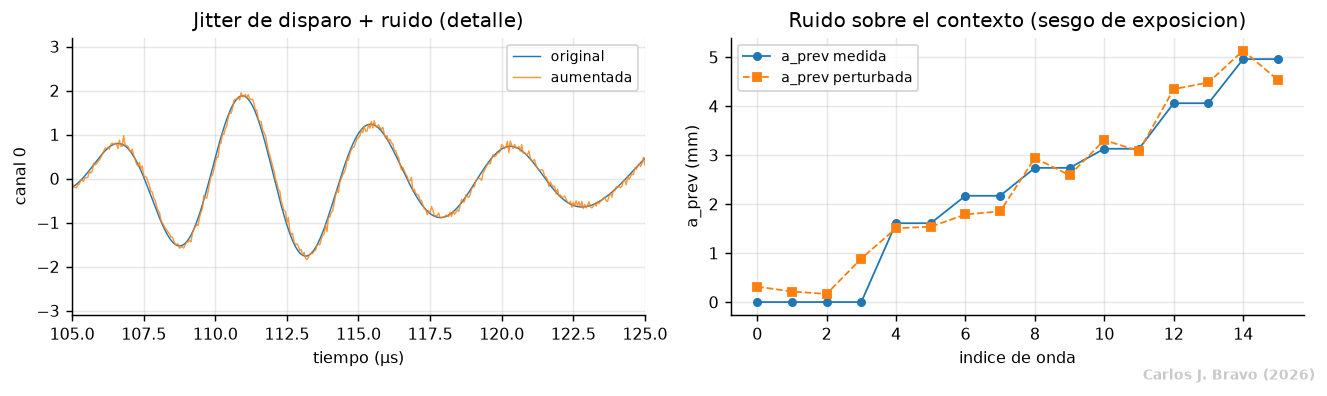

Desplazamiento maximo: +-10 muestras = +-0.50 us
La longitud de grieta previa nunca se hace negativa, pues se recorta en cero:


  valor mínimo tras perturbar = 0.166 mm


In [15]:
import torch
gen = torch.Generator().manual_seed(0)
x0 = lotes["T4"].x[:1]
x_aug = augment(x0, gen, shift=10, noise=0.05)

fig, ejes = plt.subplots(1, 2, figsize=(10.2, 3.0))
ejes[0].plot(t_v, x0[0, 0].numpy(), lw=0.8, color="tab:blue", label="original")
ejes[0].plot(t_v, x_aug[0, 0].numpy(), lw=0.8, color="tab:orange", alpha=0.8, label="aumentada")
ejes[0].set(xlim=(105, 125), xlabel="tiempo (µs)", ylabel="canal 0",
            title="Jitter de disparo + ruido (detalle)")
ejes[0].legend(fontsize=7.5)

a_prev = lotes["T4"].a_prev
perturbada = augment_previous(a_prev, gen, noise=0.4)
ejes[1].plot(a_prev.numpy(), "o-", ms=4, lw=1, color="tab:blue", label="a_prev medida")
ejes[1].plot(perturbada.numpy(), "s--", ms=4, lw=1, color="tab:orange", label="a_prev perturbada")
ejes[1].set(xlabel="indice de onda", ylabel="a_prev (mm)",
            title="Ruido sobre el contexto (sesgo de exposicion)")
ejes[1].legend(fontsize=7.5)
fig.tight_layout()
marca_de_agua(fig)
plt.show()

print(f"Desplazamiento maximo: +-10 muestras = +-{10/FS*1e6:.2f} us")
print(f"La longitud de grieta previa nunca se hace negativa, pues se recorta en cero:")
print(f"  valor mínimo tras perturbar = {float(perturbada.min()):.3f} mm")


## 10. Resumen y limitaciones

### 10.1 Salida de la cadena

Al término de esta cadena, las cuatro configuraciones reciben exactamente la misma información:

- un tensor de dimensiones (n, 2, 1100) por espécimen, con la onda estandarizada y el canal
  diferencial normalizado;
- un tensor de dimensiones (n, 13) con los rasgos escalares;
- el contexto secuencial, formado por la longitud de grieta previa y el intervalo de ciclos;
- los pares de ciclos consecutivos sobre los que se evalúa el residuo físico;
- el normalizador de la métrica del certamen y el rango de tensión equivalente del bloque de carga.

Lo que distingue a las configuraciones, esto es la integración explícita, el retardo por sobrecarga
y la autoatención, actúa con posterioridad a este punto y nunca sobre la señal.

### 10.2 Limitaciones

1. **La escala del paso 5 es transductiva.** Se calcula con registros del propio espécimen evaluado,
   lo que exige disponer de su conjunto completo de señales. Resulta legítimo bajo el protocolo del
   certamen, en el que los participantes recibieron de una vez todas las señales de cada espécimen
   de validación, pero no sería viable en una aplicación en línea, donde haría falta una estimación
   corriente.
2. **El ciclo en que se lee esa escala se selecciona por la longitud de grieta medida**, que es
   información del espécimen evaluado. Se comprueba más arriba que el ciclo resultante es anterior o
   igual al último con señal, de modo que no se emplea información posterior al corte, pero la
   dependencia existe y se declara.
3. **El tamaño del conjunto constituye la limitación de fondo**: 87 ondas etiquetadas. Ese número
   determina la capacidad admisible del codificador, la intensidad de la regularización y el margen
   por debajo del cual una diferencia entre variantes no resulta interpretable.

In [16]:
resumen = pd.DataFrame([{
    "especimen": esp,
    "x (ondas, canales, muestras)": tuple(b.x.shape),
    "rasgos escalares": tuple(b.features.shape),
    "pares del residuo": int(len(b.pair_from)),
} for esp, b in lotes.items()])
print(f"Ondas etiquetadas totales: {sum(int(b.x.shape[0]) for b in lotes.values())}")
print(f"Especímenes: {len(lotes)}  |  muestras por onda: {S.WINDOW_SAMPLES}  |  canales: 2")
resumen


Ondas etiquetadas totales: 87
Especímenes: 8  |  muestras por onda: 1100  |  canales: 2


,especimen,"x (ondas, canales, muestras)",rasgos escalares,pares del residuo
0,T1,"(14, 2, 1100)","(14, 13)",5
1,T2,"(6, 2, 1100)","(6, 13)",1
2,T3,"(18, 2, 1100)","(18, 13)",6
3,T4,"(16, 2, 1100)","(16, 13)",6
4,T5,"(5, 2, 1100)","(5, 13)",1
5,T6,"(12, 2, 1100)","(12, 13)",4
6,T7,"(8, 2, 1100)","(8, 13)",1
7,T8,"(8, 2, 1100)","(8, 13)",1
